<a href="https://colab.research.google.com/github/Jyothik178/Machine-Learning-Skill/blob/main/2420080039_week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ============================
# PART A: SIMPLE MANUAL CALCULATIONS
# ============================
print("=" * 60)
print("PART A: MANUAL CALCULATIONS")
print("=" * 60)

# 1. Create simple dataset
print("\n1. Sample Dataset:")
print("   Features: [Age, Income]")
print("   Target: Buy")
print("\n   Data:")

data = [
    [0, 0, 0],
    [0, 0, 0],
    [1, 0, 0],
    [2, 0, 0],
    [2, 1, 1],
    [2, 1, 1],
    [1, 1, 1],
    [0, 1, 0],
    [2, 0, 1],
    [0, 1, 1]
]

df = pd.DataFrame(data, columns=['Age', 'Income', 'Buy'])
print(df.to_string(index=False))


PART A: MANUAL CALCULATIONS

1. Sample Dataset:
   Features: [Age, Income]
   Target: Buy

   Data:
 Age  Income  Buy
   0       0    0
   0       0    0
   1       0    0
   2       0    0
   2       1    1
   2       1    1
   1       1    1
   0       1    0
   2       0    1
   0       1    1


In [ ]:
# ============================
# 2. CALCULATE GINI IMPURITY MANUALLY
# ============================
print("\n2. Gini Impurity Calculation:")
print("   Formula: 1 - sum(p_i^2)")

labels = df['Buy'].values
n_total = len(labels)
n_yes = sum(labels)
n_no = n_total - n_yes

p_yes = n_yes / n_total
p_no = n_no / n_total

gini = 1 - (p_yes**2 + p_no**2)

print(f"   Total: {n_total}, Yes: {n_yes}, No: {n_no}")
print(f"   P(Yes)={p_yes:.2f}, P(No)={p_no:.2f}")
print(f"   Gini = 1 - ({p_yes:.2f}^2 + {p_no:.2f}^2) = {gini:.4f}")


# ============================
# 3. CALCULATE ENTROPY MANUALLY
# ============================
print("\n3. Entropy Calculation:")
print("   Formula: -sum(p_i * log2(p_i))")

entropy = 0
if p_yes > 0:
    entropy -= p_yes * np.log2(p_yes)
if p_no > 0:
    entropy -= p_no * np.log2(p_no)

print(
    f"   Entropy = -[{p_yes:.2f}*log2({p_yes:.2f}) "
    f"+ {p_no:.2f}*log2({p_no:.2f})] = {entropy:.4f}"
)

# ============================
# 4. SIMPLE SPLIT EXAMPLE
# ============================
print("\n4. Example Split: Age <= 1")

left = df[df['Age'] <= 1]['Buy'].values
right = df[df['Age'] > 1]['Buy'].values



2. Gini Impurity Calculation:
   Formula: 1 - sum(p_i^2)
   Total: 10, Yes: 5, No: 5
   P(Yes)=0.50, P(No)=0.50
   Gini = 1 - (0.50^2 + 0.50^2) = 0.5000

3. Entropy Calculation:
   Formula: -sum(p_i * log2(p_i))
   Entropy = -[0.50*log2(0.50) + 0.50*log2(0.50)] = 1.0000

4. Example Split: Age <= 1


In [ ]:
# ============================
# GINI FOR CHILD NODES
# ============================
def simple_gini(y):
    if len(y) == 0:
        return 0
    p1 = sum(y) / len(y)
    p0 = 1 - p1
    return 1 - (p1**2 + p0**2)


gini_left = simple_gini(left)
gini_right = simple_gini(right)

# ============================
# INFORMATION GAIN
# ============================
weighted_gini = (
    (len(left) / n_total) * gini_left +
    (len(right) / n_total) * gini_right
)

gain = gini - weighted_gini

print(f"   Left branch (Age <= 1): {list(left)}")
print(f"   Right branch (Age > 1): {list(right)}")
print(f"   Gini(left) = {gini_left:.4f}")
print(f"   Gini(right) = {gini_right:.4f}")
print(f"   Weighted average = {weighted_gini:.4f}")
print(f"   Information Gain = {gini:.4f} - {weighted_gini:.4f} = {gain:.4f}")

# ============================
# PART B: IRIS DATASET ANALYSIS
# ============================
print("\n" + "=" * 60)
print("PART B: IRIS DATASET ANALYSIS")
print("=" * 60)


   Left branch (Age <= 1): [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]
   Right branch (Age > 1): [np.int64(0), np.int64(1), np.int64(1), np.int64(1)]
   Gini(left) = 0.4444
   Gini(right) = 0.3750
   Weighted average = 0.4167
   Information Gain = 0.5000 - 0.4167 = 0.0833

PART B: IRIS DATASET ANALYSIS



1. Load Iris Dataset
   Samples: 150
   Features used: ['sepal length (cm)', 'sepal width (cm)']
   Classes: ['setosa' 'versicolor' 'virginica']

2. Data Split
   Train: 105 samples
   Test: 45 samples

3. Train Decision Trees

4. Model Performance
   Gini Accuracy: 0.756
   Entropy Accuracy: 0.667

5. Visualize Trees


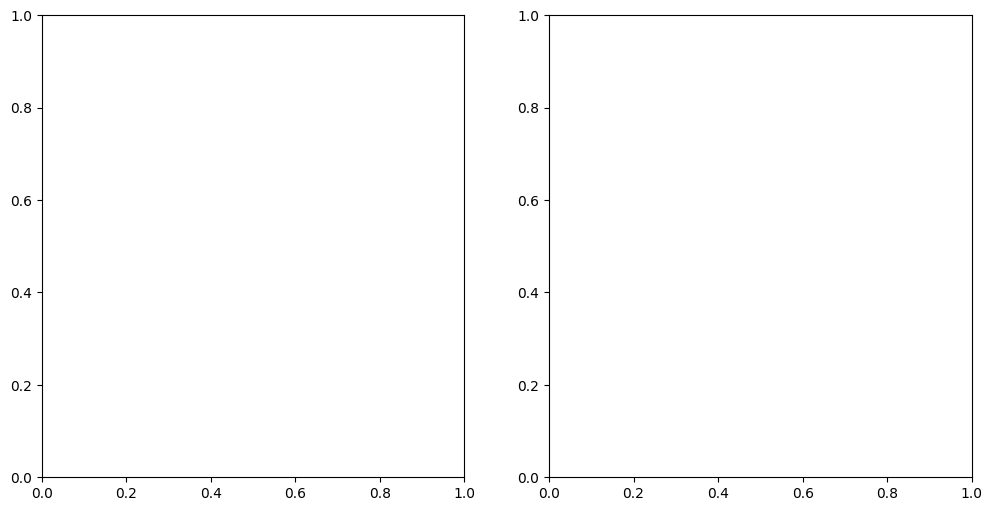

In [ ]:
# ============================
# 1. LOAD IRIS DATASET
# ============================
print("\n1. Load Iris Dataset")

iris = load_iris()
X, y = iris.data, iris.target

feature_names = iris.feature_names[:2]  # Use only 2 features for simplicity
target_names = iris.target_names

print(f"   Samples: {len(X)}")
print(f"   Features used: {feature_names}")
print(f"   Classes: {target_names}")

# ============================
# 2. SPLIT DATA
# ============================
X_simple = X[:, :2]  # Use only 2 features for simplicity

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.3,
    random_state=42
)

print(f"\n2. Data Split")
print(f"   Train: {len(X_train)} samples")
print(f"   Test: {len(X_test)} samples")

# ============================
# 3. TRAIN DECISION TREES
# ============================
print("\n3. Train Decision Trees")

# Train with Gini
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42,
    max_depth=3
)
dt_gini.fit(X_train, y_train)

# Train with Entropy
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth=3
)
dt_entropy.fit(X_train, y_train)

# ============================
# 4. EVALUATE MODELS
# ============================
print("\n4. Model Performance")

y_pred_gini = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

acc_gini = accuracy_score(y_test, y_pred_gini)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"   Gini Accuracy: {acc_gini:.3f}")
print(f"   Entropy Accuracy: {acc_entropy:.3f}")

# ============================
# 5. VISUALIZE TREES
# ============================
print("\n5. Visualize Trees")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))


In [ ]:
# ============================
# GINI TREE
# ============================
plot_tree(
    dt_gini,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    ax=ax1
)
ax1.set_title('Gini Criterion')

# ============================
# ENTROPY TREE
# ============================
plot_tree(
    dt_entropy,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    ax=ax2
)
ax2.set_title('Entropy Criterion')

plt.tight_layout()
plt.savefig('simple_trees.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================
# 6. FEATURE IMPORTANCE
# ============================
print("\n6. Feature Importance")
print("   Gini Importance:")
for name, imp in zip(feature_names, dt_gini.feature_importances_):
    print(f"     {name}: {imp:.3f}")

print("\n   Entropy Importance:")
for name, imp in zip(feature_names, dt_entropy.feature_importances_):
    print(f"     {name}: {imp:.3f}")

# ============================
# 7. SIMPLE PRUNING TEST
# ============================
print("\n7. Test Pruning (max_depth)")
depths = [1, 2, 3, 4, 5]

print("   Depth | Gini Acc | Entropy Acc")
print("   " + "-" * 30)

for depth in depths:
    # Gini
    dt_g = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )
    dt_g.fit(X_train, y_train)
    acc_g = accuracy_score(y_test, dt_g.predict(X_test))

    # Entropy
    dt_e = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=42
    )
    dt_e.fit(X_train, y_train)
    acc_e = accuracy_score(y_test, dt_e.predict(X_test))

    print(f"   {depth:5d} | {acc_g:8.3f} | {acc_e:10.3f}")


<Figure size 640x480 with 0 Axes>


6. Feature Importance
   Gini Importance:
     sepal length (cm): 0.723
     sepal width (cm): 0.277

   Entropy Importance:
     sepal length (cm): 0.686
     sepal width (cm): 0.314

7. Test Pruning (max_depth)
   Depth | Gini Acc | Entropy Acc
   ------------------------------
       1 |    0.644 |      0.667
       2 |    0.756 |      0.711
       3 |    0.756 |      0.667
       4 |    0.756 |      0.800
       5 |    0.756 |      0.756
